# Práctica 3 — Generación de Variables Aleatorias Continuas

Universidad del Valle de Guatemala — Facultad de Ingeniería

Ciencia de la Computación y Tecnologías de la Información

CC2017 - Modelación y Simulación — Ciclo 2, 2026

DIEGO JAVIER LÓPEZ REINOSO #23747

## Ejercicio 1

Sea $X$ una variable aleatoria exponencial con media 1. Proporcione un algoritmo eficiente para simular una variable aleatoria cuya distribución es la distribución condicional de $X$ dado que $X < 0.05$. Es decir, su función de densidad es

$$f(x) = \dfrac{e^{-x}}{1 - e^{-0.05}}, \qquad 0 < x < 0.05.$$

Genere 1000 de estas variables y utilícelas para estimar $E[X \mid X < 0.05]$. Luego determine el valor exacto de $E[X \mid X < 0.05]$.

In [1]:
import numpy as np
import math



def generar_exp_truncada(n, limite=0.05, seed=None):
    rng = np.random.default_rng(seed)
    u = rng.random(n)
    return -np.log(1 - u * (1 - math.exp(-limite)))

n = 1000
muestras = generar_exp_truncada(n, seed=42)

media_estimada = muestras.mean()

# valor exacto de E[X | X < 0.05], integrando x*f(x) por partes
limite = 0.05
media_exacta = (1 - (1 + limite) * math.exp(-limite)) / (1 - math.exp(-limite))

print(f"media estimada (n={n}): {media_estimada:.6f}")
print(f"media exacta:           {media_exacta:.6f}")
print(f"diferencia:              {abs(media_estimada - media_exacta):.6f}")


media estimada (n=1000): 0.024653
media exacta:           0.024792
diferencia:              0.000139


## Ejercicio 2 (Método de composición)

Suponga que es relativamente fácil generar variables aleatorias a partir de cualquiera de las distribuciones $F_i$, $i = 1, \dots, n$. ¿Cómo podríamos generar una variable aleatoria con función de distribución

$$F(x) = \sum_{i=1}^{n} p_i F_i(x)$$

donde $p_i$, $i = 1, \dots, n$, son números no negativos cuya suma es 1?

### R//

La idea es que F(x) es una mezcla de las Fi, ponderada por los pi. Entonces se puede generar en dos pasos:

1. Se elige un índice I al azar, donde P(I = i) = pi (por ejemplo con transformada inversa discreta sobre los pi).
2. Ya sabiendo qué i salió, se genera X con la distribución Fi correspondiente.

Ese X termina teniendo distribución F(x), porque por probabilidad total:

$$P(X \le x) = \sum_{i=1}^{n} P(X \le x \mid I=i)\, P(I=i) = \sum_{i=1}^{n} F_i(x)\, p_i = F(x)$$

A esto se le llama método de composición, y sirve cuando F es complicada de invertir directamente pero se puede escribir como combinación de Fi's que sí son fáciles de generar.

## Ejercicio 3

Utilizando el resultado del Ejercicio 2, proporcione algoritmos para generar variables aleatorias a partir de las siguientes distribuciones.

**(a)**
$$F(x) = \dfrac{x + x^3 + x^5}{3}, \qquad 0 \le x \le 1$$

### R//

F(x) = (1/3)x + (1/3)x³ + (1/3)x⁵, mezcla de F1(x)=x, F2(x)=x³, F3(x)=x⁵ con p1=p2=p3=1/3.

Cada Fi(x)=x^k corresponde a la variable U^(1/k) con U~Unif(0,1):

P(U^(1/k) ≤ x)
= P(U ≤ x^k)
= x^k

Algoritmo:
1. Generar U1 ~ Unif(0,1) y elegir k ∈ {1,3,5} con probabilidad 1/3 cada uno.
2. Generar U2 ~ Unif(0,1).
3. X = U2^(1/k).

**(b)**
$$F(x) = \begin{cases} \dfrac{1 - e^{-2x} + 2x}{3} & 0 < x < 1 \\[2mm] \dfrac{3 - e^{-2x}}{3} & 1 < x < \infty \end{cases}$$

### R//

F(x) = (1/3)F1(x) + (2/3)F2(x), donde:
- F1(x) = 1 - e^(-2x), 0 < x < ∞ → exponencial de tasa 2.
- F2(x) = x para 0<x<1 y 1 para x≥1 → uniforme(0,1).

Verificación, para 0<x<1:

(1/3)(1-e^(-2x)) + (2/3)x
= (1-e^(-2x))/3 + 2x/3
= (1-e^(-2x)+2x)/3

coincide con el primer tramo.

Verificación, para x≥1:

(1/3)(1-e^(-2x)) + (2/3)(1)
= 1/3 - e^(-2x)/3 + 2/3
= (3-e^(-2x))/3

coincide con el segundo tramo.

Algoritmo:
1. Generar U1 ~ Unif(0,1). Si U1 ≤ 1/3, ir al paso 2a; si no, ir al paso 2b.
2a. Generar U2 ~ Unif(0,1) y hacer X = -ln(U2)/2 (exponencial de tasa 2).
2b. Generar X ~ Unif(0,1) directamente.

**(c)**
$$F(x) = \sum_{i=1}^{n} \alpha_i x^i, \qquad 0 \le x \le 1, \quad \text{donde } \alpha_i \ge 0, \quad \sum_{i=1}^{n} \alpha_i = 1$$

### R//

Generalización de (a): F(x) = Σ αi·Fi(x), con Fi(x) = x^i y peso αi para cada i=1,...,n.

Igual que antes, Fi(x)=x^i es la CDF de U^(1/i) con U~Unif(0,1).

Algoritmo:
1. Elegir un índice i ∈ {1,...,n} con probabilidad αi.
2. Generar U ~ Unif(0,1).
3. X = U^(1/i).

## Ejercicio 4

Una compañía de seguros contra siniestros tiene 1000 asegurados, cada uno de los cuales presentará una reclamación en el próximo mes de manera independiente con probabilidad 0.05. Suponiendo que los montos de las reclamaciones son variables aleatorias exponenciales independientes con media \$800, utilice simulación para estimar la probabilidad de que la suma de estas reclamaciones exceda \$50,000.

In [2]:
rng = np.random.default_rng(42)

n_asegurados = 1000
p_reclama = 0.05
media_monto = 800
umbral = 50_000
n_simulaciones = 100_000

# por cada simulacion: cuantos reclaman (binomial) y la suma de sus montos (exponencial)
n_reclamos = rng.binomial(n_asegurados, p_reclama, size=n_simulaciones)
sumas = np.array([rng.exponential(media_monto, k).sum() for k in n_reclamos])

prob_estimada = (sumas > umbral).mean()
print(f"P(suma > {umbral}) estimada: {prob_estimada:.4f}")


P(suma > 50000) estimada: 0.1063


## Ejercicio 5

Escriba un programa que genere variables aleatorias normales utilizando el método del Ejemplo 5f (método de rechazo con una distribución exponencial de tasa 1).

### Material de apoyo: Ejemplo 5f — Generación de una variable aleatoria normal

Para generar una variable aleatoria normal estándar $Z$ (es decir, con media 0 y varianza 1), se observa primero que el valor absoluto de $Z$ tiene función de densidad

$$f(x) = \sqrt{\dfrac{2}{\pi}}\, e^{-x^2/2}, \qquad 0 < x < \infty.$$

Esta densidad se genera usando el **método de rechazo**, tomando como densidad auxiliar $g$ la exponencial de media 1, es decir $g(x) = e^{-x}$, $0 < x < \infty$. Entonces

$$\dfrac{f(x)}{g(x)} = \sqrt{2/\pi}\; e^{\,x - x^2/2},$$

cuyo máximo ocurre en $x = 1$, lo que da la constante

$$c = \max_x \dfrac{f(x)}{g(x)} = \dfrac{f(1)}{g(1)} = \sqrt{2e/\pi}.$$

Como $\dfrac{f(x)}{c\,g(x)} = \exp\left\{-\dfrac{(x-1)^2}{2}\right\}$, se obtiene el siguiente algoritmo para generar el valor absoluto de una normal estándar:

- **Paso 1:** Genere $Y$, una exponencial con tasa 1.
- **Paso 2:** Genere un número aleatorio $U$.
- **Paso 3:** Si $U \le \exp\{-(Y-1)^2/2\}$, haga $X = Y$. En caso contrario, regrese al Paso 1.

Una vez generado $X$ (que se distribuye como el valor absoluto de una normal estándar), se obtiene $Z$ haciendo que sea igualmente probable que valga $X$ o $-X$ (esto se decide con un número aleatorio adicional: si $U \le 1/2$ entonces $Z = X$; si no, $Z = -X$).

Puede demostrarse además que la condición de aceptación del Paso 3 es equivalente a $-\log U \ge (Y-1)^2/2$, y como $-\log U$ es exponencial de tasa 1, se obtiene la siguiente versión equivalente, que genera simultáneamente una normal estándar y — como subproducto — una exponencial independiente de tasa 1:

- **Paso 1:** Genere $Y_1$, exponencial con tasa 1.
- **Paso 2:** Genere $Y_2$, exponencial con tasa 1.
- **Paso 3:** Si $Y_2 - (Y_1-1)^2/2 > 0$, haga $Y = Y_2 - (Y_1-1)^2/2$ y continúe al Paso 4. En caso contrario, regrese al Paso 1.
- **Paso 4:** Genere un número aleatorio $U$ y haga

$$Z = \begin{cases} Y_1 & \text{si } U \le 1/2 \\ -Y_1 & \text{si } U > 1/2 \end{cases}$$

$Z$ (normal estándar) e $Y$ (exponencial de tasa 1) resultan independientes. Dado que $c = \sqrt{2e/\pi} \approx 1.32$, en promedio el algoritmo requiere generar 1.64 exponenciales y calcular 1.32 cuadrados por cada normal generada. (Si se desea una normal de media $\mu$ y varianza $\sigma^2$, basta con tomar $\mu + \sigma Z$.)

In [3]:
rng = np.random.default_rng(42)

def generar_normal():
    # metodo de rechazo con exponencial(1), version de los pasos 1-4
    while True:
        y1 = rng.exponential(1)
        y2 = rng.exponential(1)
        if y2 - (y1 - 1)**2 / 2 > 0:
            break
    u = rng.random()
    return y1 if u <= 0.5 else -y1

n = 1000
normales = np.array([generar_normal() for _ in range(n)])

print(f"media muestral:    {normales.mean():.4f}")
print(f"varianza muestral: {normales.var():.4f}")


media muestral:    -0.0045
varianza muestral: 1.0216


## Ejercicio 6

Escriba un programa que genere las primeras $T$ unidades de tiempo de un proceso de Poisson con tasa $\lambda$.

In [4]:
def poisson_homogeneo(lam, T, rng):
    tiempos = []
    t = 0
    while True:
        t += rng.exponential(1 / lam)
        if t > T:
            break
        tiempos.append(t)
    return tiempos

rng = np.random.default_rng(42)
tiempos = poisson_homogeneo(lam=2, T=10, rng=rng)

print(f"eventos generados: {len(tiempos)}")
print(f"tiempos: {[round(t, 3) for t in tiempos]}")


eventos generados: 18
tiempos: [1.202, 2.37, 3.563, 3.702, 3.746, 4.472, 5.177, 6.739, 6.779, 7.302, 7.337, 7.882, 8.747, 8.941, 9.557, 9.634, 9.679, 9.837]


## Ejercicio 7

**(a)** Escriba un programa que utilice el algoritmo de adelgazamiento (*thinning*) para generar las primeras 10 unidades de tiempo de un proceso de Poisson no homogéneo con función de intensidad

$$\lambda(t) = 3 + \dfrac{4}{t+1}$$

In [5]:
def lam(t):
    return 3 + 4 / (t + 1)

def poisson_thinning(lam_func, lam_max, T, rng):
    tiempos = []
    t = 0
    while True:
        t += rng.exponential(1 / lam_max)
        if t > T:
            break
        if rng.random() <= lam_func(t) / lam_max:
            tiempos.append(t)
    return tiempos

# lambda(t) es decreciente en [0,10], entonces el maximo es lambda(0) = 7
lam_max = lam(0)

rng = np.random.default_rng(42)
tiempos = poisson_thinning(lam, lam_max, T=10, rng=rng)

print(f"eventos generados: {len(tiempos)}")
print(f"tiempos: {[round(t, 3) for t in tiempos]}")


eventos generados: 37
tiempos: [0.343, 0.684, 0.909, 1.343, 1.356, 1.484, 1.663, 2.019, 2.084, 2.266, 2.332, 2.381, 2.852, 3.174, 3.22, 3.271, 3.958, 4.112, 4.778, 4.784, 4.873, 5.163, 5.17, 6.027, 6.046, 6.063, 6.308, 6.363, 6.574, 6.647, 7.572, 7.623, 8.39, 8.539, 8.711, 8.946, 9.922]


**(b)** Proponga una manera de mejorar el algoritmo de adelgazamiento para este ejemplo.

### R//

El thinning normal usa una sola cota λ_max = λ(0) = 7 para todo el intervalo [0,10]. El problema es que λ(t) es decreciente, entonces cerca de t=10 la tasa real es λ(10)=3.36, muy por debajo de 7, y se generan muchos candidatos que se rechazan sin necesidad.

Mejora: partir el intervalo en tramos y usar en cada uno la cota local (el valor de λ(t) al inicio del tramo, ya que es decreciente). Así el paso de propuesta usa una tasa más cercana a la real y se rechaza menos.

Ejemplo con tramos de tamaño 2:
- [0,2): cota = λ(0) = 7
- [2,4): cota = λ(2) = 4.33
- [4,6): cota = λ(4) = 3.8
- [6,8): cota = λ(6) = 3.57
- [8,10): cota = λ(8) = 3.44

Con esto la tasa de aceptación λ(t)/cota sube en cada tramo comparado con usar 7 en todo el intervalo.

## Ejercicio 8

Escriba un programa para generar los puntos de un proceso de Poisson bidimensional dentro de un círculo de radio $R$, y ejecute el programa para $\lambda = 1$ y $R = 5$. Grafique los puntos obtenidos.

puntos generados: 86


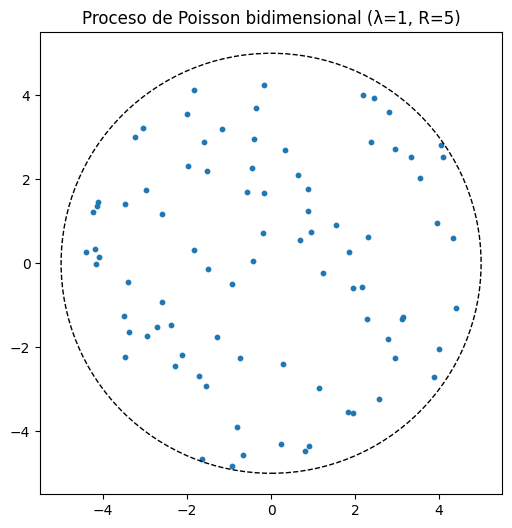

In [6]:
import matplotlib.pyplot as plt

def poisson_bidimensional_circulo(lam, R, rng):
    area = math.pi * R**2
    n_puntos = rng.poisson(lam * area)
    # radio con sqrt(uniforme) para que la densidad sea uniforme en el area, no en el radio
    r = R * np.sqrt(rng.random(n_puntos))
    theta = rng.uniform(0, 2 * math.pi, n_puntos)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

rng = np.random.default_rng(42)
x, y = poisson_bidimensional_circulo(lam=1, R=5, rng=rng)

print(f"puntos generados: {len(x)}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, s=10)
ax.add_patch(plt.Circle((0, 0), 5, fill=False, linestyle="--"))
ax.set_aspect("equal")
ax.set_title("Proceso de Poisson bidimensional (λ=1, R=5)")
plt.show()


## Ejercicio 9

Explique el método polar para generar variables aleatorias normales. Su explicación debe incluir:

**(a)** En qué consiste el método (idea general y algoritmo paso a paso).

### R//

El método polar genera un par de normales estándar independientes (X, Y) usando coordenadas polares en vez de senos y cosenos.

Algoritmo:
1. Generar U1, U2 ~ Unif(0,1).
2. V1 = 2U1 - 1, V2 = 2U2 - 1 (esto los manda a (-1,1)).
3. S = V1² + V2².
4. Si S > 1, volver al paso 1 (el punto (V1,V2) cayó fuera del círculo unitario).
5. Si S ≤ 1, calcular:

X = V1 · sqrt(-2 ln(S) / S)
Y = V2 · sqrt(-2 ln(S) / S)

**(b)** Para qué sirve (qué problema resuelve y por qué es preferible frente al uso directo de las transformaciones de Box–Muller).

### R//

Box-Muller genera dos normales calculando seno y coseno de 2πU, lo cual es costoso computacionalmente (funciones trigonométricas). El método polar evita eso: usa un paso de rechazo para simular el ángulo y el radio de forma indirecta, sin llamar seno ni coseno. Como contraparte, tiene que rechazar los puntos fuera del círculo unitario (en promedio se acepta π/4 ≈ 78.5% de los intentos), pero esa pérdida sale más barata que calcular trigonometría en cada muestra.

**(c)** Un ejemplo numérico: elija valores de $U_1$ y $U_2$ y aplique el algoritmo paso a paso hasta obtener el par de normales $X, Y$ (si el primer par $(V_1, V_2)$ cae fuera del círculo unitario, elija un segundo par y continúe).

### R//

Intento 1 — U1=0.9, U2=0.95:
V1 = 2(0.9)-1 = 0.8
V2 = 2(0.95)-1 = 0.9
S = 0.8² + 0.9² = 1.45 > 1 → se rechaza, se repite el paso 1.

Intento 2 — U1=0.6, U2=0.3:
V1 = 2(0.6)-1 = 0.2
V2 = 2(0.3)-1 = -0.4
S = 0.2² + (-0.4)² = 0.2 ≤ 1 → se acepta.

factor = sqrt(-2 ln(0.2) / 0.2) = 4.0118

X = 0.2 · 4.0118 = 0.8024
Y = -0.4 · 4.0118 = -1.6047

## Ejercicio 10

Explique el proceso de Poisson bidimensional y el algoritmo para simularlo dentro de una región circular. Su explicación debe incluir:

**(a)** En qué consiste (definición formal del proceso y el algoritmo de simulación paso a paso).

### R//

Un proceso de Poisson bidimensional con tasa λ asigna a cada región A del plano un número de puntos N(A) que se distribuye Poisson(λ·área(A)), y los conteos en regiones disjuntas son independientes.

Para simularlo dentro de un círculo de radio r:
1. Generar N ~ Poisson(λ·π·r²), el número total de puntos.
2. Para cada uno de los N puntos, generar su posición de forma independiente y uniforme dentro del círculo:
   - Generar U1 ~ Unif(0,1) y hacer R = r·sqrt(U1) (el sqrt es para que la densidad sea uniforme en área, no en radio).
   - Generar U2 ~ Unif(0,1) y hacer Θ = 2π·U2.
3. El punto queda como (R, Θ) en polares, o (R cos Θ, R sen Θ) en cartesianas.

**(b)** Para qué sirve (qué tipo de fenómenos se pueden modelar con este proceso y por qué es útil poder simularlo).

### R//

Sirve para modelar fenómenos donde eventos caen al azar sobre un área: ubicación de árboles en un bosque, impactos de meteoritos, posiciones de estrellas en una región del cielo, distribución de antenas o de clientes en un mapa, defectos en una superficie, etc. Poder simularlo permite generar escenarios sintéticos de estos fenómenos para probar modelos o estimar cantidades (como el número esperado de puntos en una subregión) sin depender solo de datos reales.

### R//

λ=1, r=2. Área = π·2² = 12.566, entonces N ~ Poisson(12.566). Para el ejemplo se fija N=3 (un valor cualquiera que pudo haber salido de esa Poisson).

Para cada punto se generan U1 y U2, y se calcula R = 2·sqrt(U1), Θ = 2π·U2:

Punto 1: U1=0.25, U2=0.10 → R=1.000, Θ=0.628
Punto 2: U1=0.81, U2=0.50 → R=1.800, Θ=3.142
Punto 3: U1=0.49, U2=0.75 → R=1.400, Θ=4.712

### R//